<a href="https://colab.research.google.com/github/ShachiPradhan/ames-housing/blob/main/ameshousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files
uploaded = files.upload()

Saving AmesHousing.csv to AmesHousing.csv


In [12]:
import os
os.makedirs('data', exist_ok=True)
os.rename('AmesHousing.csv', 'data/AmesHousing.csv')

In [13]:
# ============================================================
# CELL 1: Setup — download data, import libraries
# ===========================================================

# NOTE: If you already uploaded your own AmesHousing.csv into data/,
# comment out the two lines above and keep your file.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Setup complete ✅")


Setup complete ✅


In [14]:
# ============================================================
# CELL 2: Load the dataset
# ============================================================

# Option A: load the raw AmesHousing.csv you downloaded
df = pd.read_csv('data/AmesHousing.csv')

# If your file has an 'Order' column, drop it
if 'Order' in df.columns:
    df = df.drop(columns=['Order'])

# If your file has a 'PID' column, set it as index
if 'PID' in df.columns:
    df = df.set_index('PID')

# Standardize column names (remove spaces + fix casing)
# This is important because the raw AmesHousing.csv uses spaces
df.columns = (df.columns
                .str.replace(' ', '', regex=False))

# Show info
print("Shape:", df.shape)
print("\nColumns (first 10):")
print(df.columns[:10].tolist())
df.head()

Shape: (2930, 80)

Columns (first 10):
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig']


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,
526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [15]:
# ============================================================
# CELL 3: Sanity check
# ============================================================
print("Shape:", df.shape)
print("Total nulls:", df.isnull().sum().sum())
print("Numeric columns:", df.select_dtypes(include='number').shape[1])
print("Object columns:", df.select_dtypes(include='object').shape[1])

print("\nColumn data types:")
print(df.dtypes.value_counts())

print("\nUnique values in a few key columns:")
for c in ['SalePrice', 'TotRmsAbvGrd', 'OverallCond', 'YrSold', 'YearBuilt']:
    if c in df.columns:
        print(f"  {c}: min={df[c].min()}, max={df[c].max()}, dtype={df[c].dtype}")

Shape: (2930, 80)
Total nulls: 15749
Numeric columns: 37
Object columns: 43

Column data types:
object     43
int64      26
float64    11
Name: count, dtype: int64

Unique values in a few key columns:
  SalePrice: min=12789, max=755000, dtype=int64
  TotRmsAbvGrd: min=2, max=15, dtype=int64
  OverallCond: min=1, max=9, dtype=int64
  YrSold: min=2006, max=2010, dtype=int64
  YearBuilt: min=1872, max=2010, dtype=int64


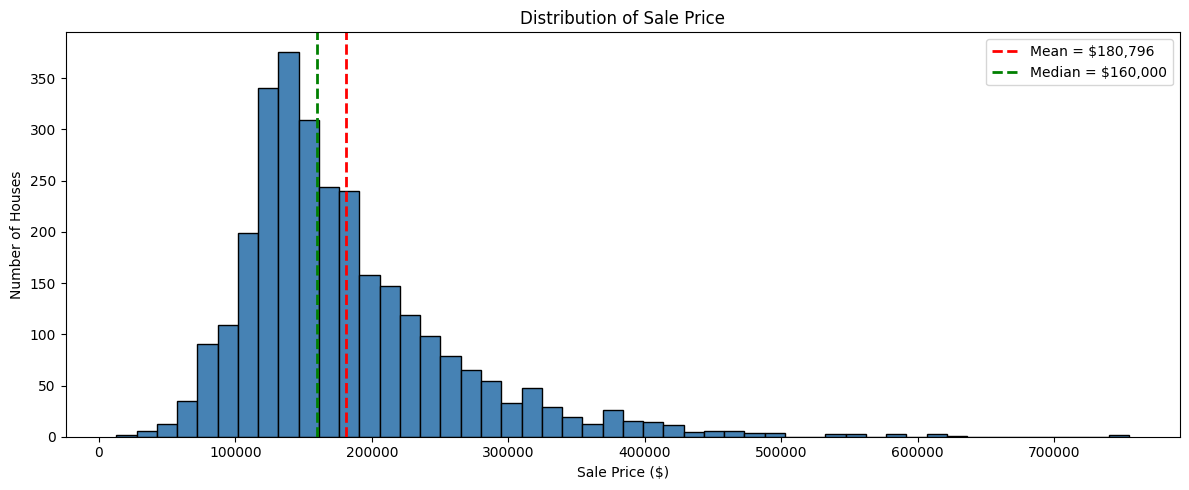

Mean:    180796.06
Median:  160000.0
Std:     79886.69
Skew:    1.744


In [16]:
# ============================================================
# CELL 4: SalePrice — histogram + stats
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
ax.axvline(df['SalePrice'].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='green', linestyle='--',
           linewidth=2, label=f"Median = ${df['SalePrice'].median():,.0f}")
ax.set_title('Distribution of Sale Price')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

print("Mean:   ", round(df['SalePrice'].mean(), 2))
print("Median: ", round(df['SalePrice'].median(), 2))
print("Std:    ", round(df['SalePrice'].std(), 2))
print("Skew:   ", round(df['SalePrice'].skew(), 3))

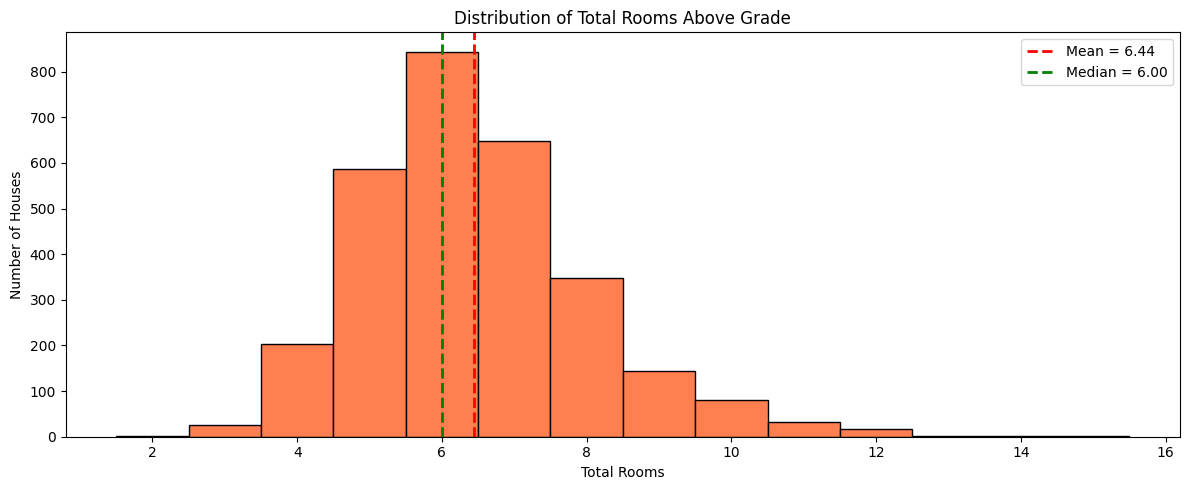

Mean:    6.44
Median:  6.0
Std:     1.57


In [17]:
# ============================================================
# CELL 5: TotRmsAbvGrd — histogram + stats
# ============================================================
col = 'TotRmsAbvGrd'

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[col],
        bins=range(int(df[col].min()), int(df[col].max()) + 2),
        color='coral', edgecolor='black', align='left')
ax.axvline(df[col].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = {df[col].mean():.2f}")
ax.axvline(df[col].median(), color='green', linestyle='--',
           linewidth=2, label=f"Median = {df[col].median():.2f}")
ax.set_title('Distribution of Total Rooms Above Grade')
ax.set_xlabel('Total Rooms')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

print("Mean:   ", round(df[col].mean(), 2))
print("Median: ", round(df[col].median(), 2))
print("Std:    ", round(df[col].std(), 2))

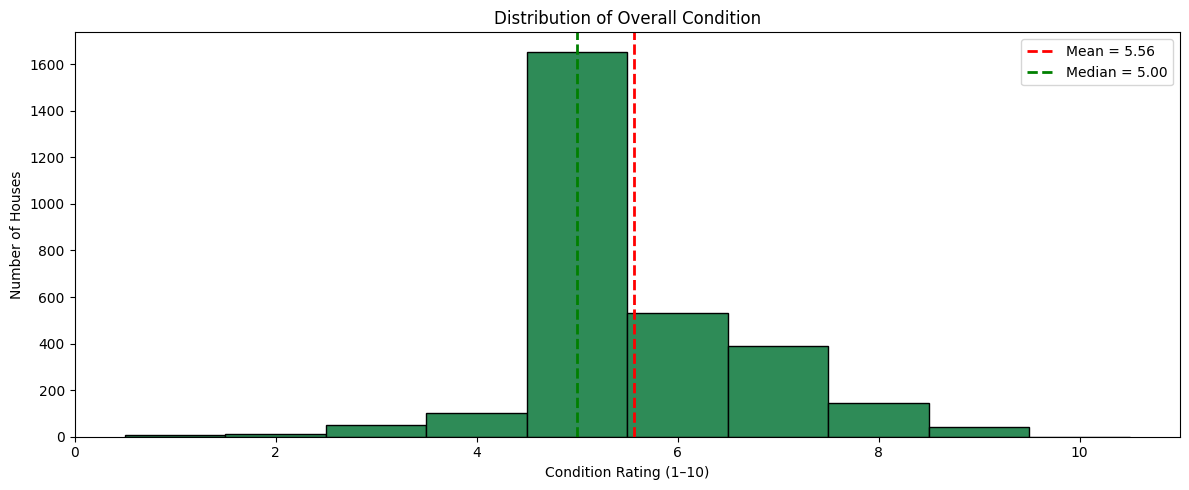

Mean:    5.56
Median:  5.0
Std:     1.11

Value counts (sorted):
OverallCond
1       7
2      10
3      50
4     101
5    1654
6     533
7     390
8     144
9      41
Name: count, dtype: int64


In [18]:
# ============================================================
# CELL 6: OverallCond — histogram + stats
# ============================================================
col = 'OverallCond'

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[col], bins=range(1, 12), color='seagreen',
        edgecolor='black', align='left')
ax.axvline(df[col].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = {df[col].mean():.2f}")
ax.axvline(df[col].median(), color='green', linestyle='--',
           linewidth=2, label=f"Median = {df[col].median():.2f}")
ax.set_title('Distribution of Overall Condition')
ax.set_xlabel('Condition Rating (1–10)')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

print("Mean:   ", round(df[col].mean(), 2))
print("Median: ", round(df[col].median(), 2))
print("Std:    ", round(df[col].std(), 2))
print("\nValue counts (sorted):")
print(df[col].value_counts().sort_index())

Below average: 168 rows
Average:       1654 rows
Above average: 1108 rows


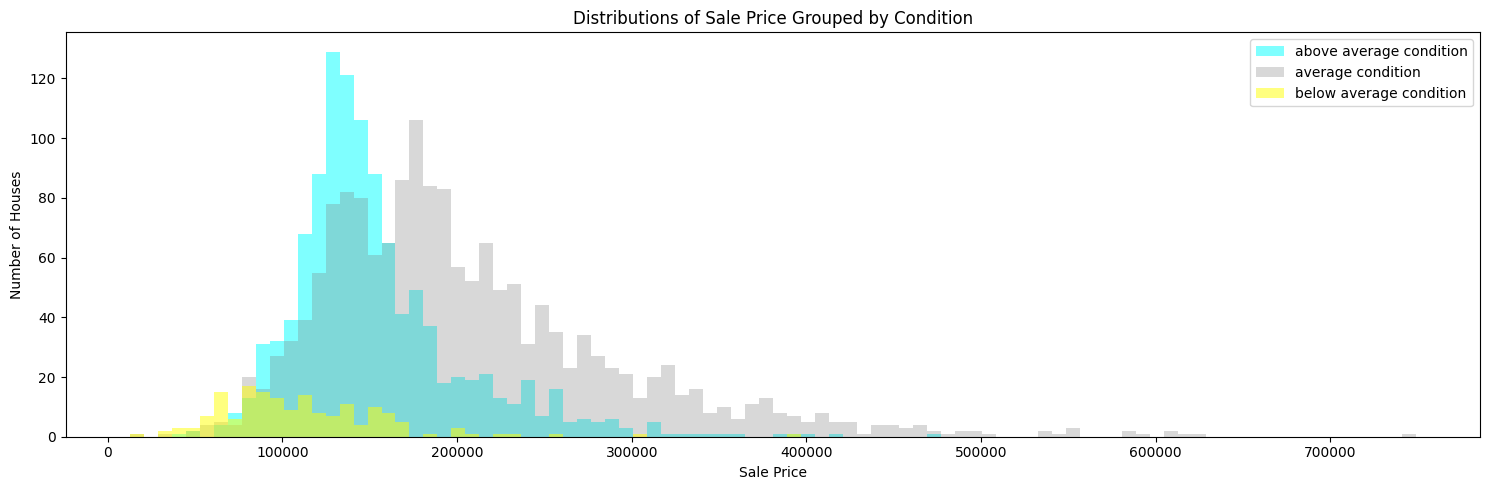

In [19]:
# ============================================================
# CELL 7: Subsets based on OverallCond
# ============================================================
below_average_condition = df[df['OverallCond'] < 5]
average_condition       = df[df['OverallCond'] == 5]
above_average_condition = df[df['OverallCond'] > 5]

print("Below average:", below_average_condition.shape[0], "rows")
print("Average:      ", average_condition.shape[0], "rows")
print("Above average:", above_average_condition.shape[0], "rows")

# Set up plot
fig, ax = plt.subplots(figsize=(15, 5))

# Custom bins so all histograms share the same scale
bins = range(int(df['SalePrice'].min()),
             int(df['SalePrice'].max()),
             int(df['SalePrice'].median()) // 20)

# Three overlapping histograms with transparency
ax.hist(above_average_condition['SalePrice'],
        label='above average condition', bins=bins, color='cyan', alpha=0.5)
ax.hist(average_condition['SalePrice'],
        label='average condition', bins=bins, color='gray', alpha=0.3)
ax.hist(below_average_condition['SalePrice'],
        label='below average condition', bins=bins, color='yellow', alpha=0.5)

ax.set_title('Distributions of Sale Price Grouped by Condition')
ax.set_xlabel('Sale Price')
ax.set_ylabel('Number of Houses')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CELL 8: Correlations with SalePrice
# ============================================================
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

# Most positive (skip SalePrice itself, which is at index 0)
most_pos_col = corr.index[1]
most_pos_val = corr.iloc[1]

# Most negative
most_neg_col = corr.index[-1]
most_neg_val = corr.iloc[-1]

print(f"Most positively correlated: {most_pos_col} ({most_pos_val:.3f})")
print(f"Most negatively correlated: {most_neg_col} ({most_neg_val:.3f})")

print("\nTop 10 correlations with SalePrice:")
print(corr.head(11).round(3))

Most positively correlated: OverallQual (0.799)
Most negatively correlated: EnclosedPorch (-0.129)

Top 10 correlations with SalePrice:
SalePrice        1.000
OverallQual      0.799
GrLivArea        0.707
GarageCars       0.648
GarageArea       0.640
TotalBsmtSF      0.632
1stFlrSF         0.622
YearBuilt        0.558
FullBath         0.546
YearRemod/Add    0.533
GarageYrBlt      0.527
Name: SalePrice, dtype: float64


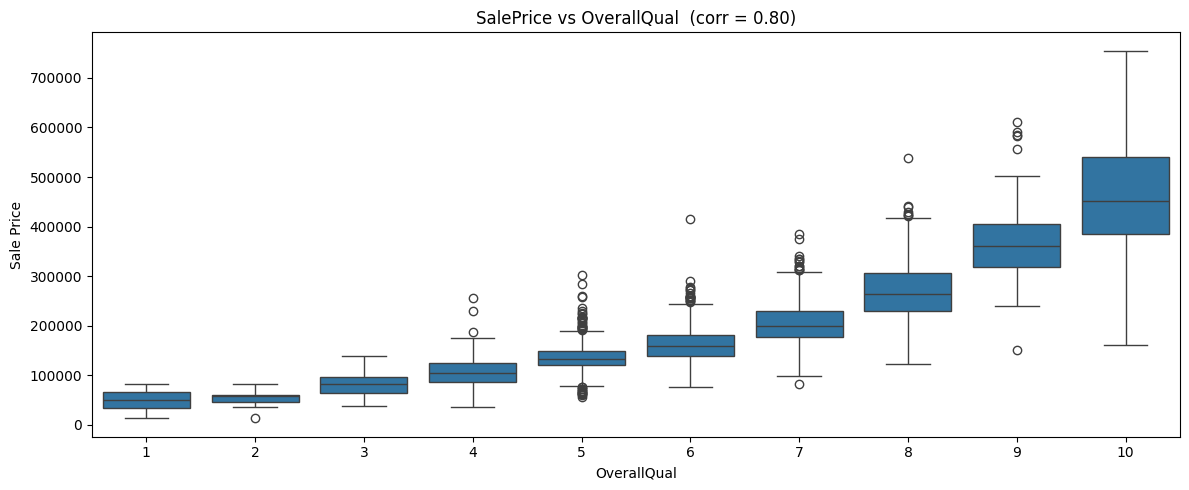

In [21]:
# ============================================================
# CELL 9: Box plot — most positively correlated feature
# ============================================================
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x=df[most_pos_col], y=df['SalePrice'], ax=ax)
ax.set_title(f'SalePrice vs {most_pos_col}  (corr = {most_pos_val:.2f})')
ax.set_xlabel(most_pos_col)
ax.set_ylabel('Sale Price')
plt.tight_layout()
plt.show()

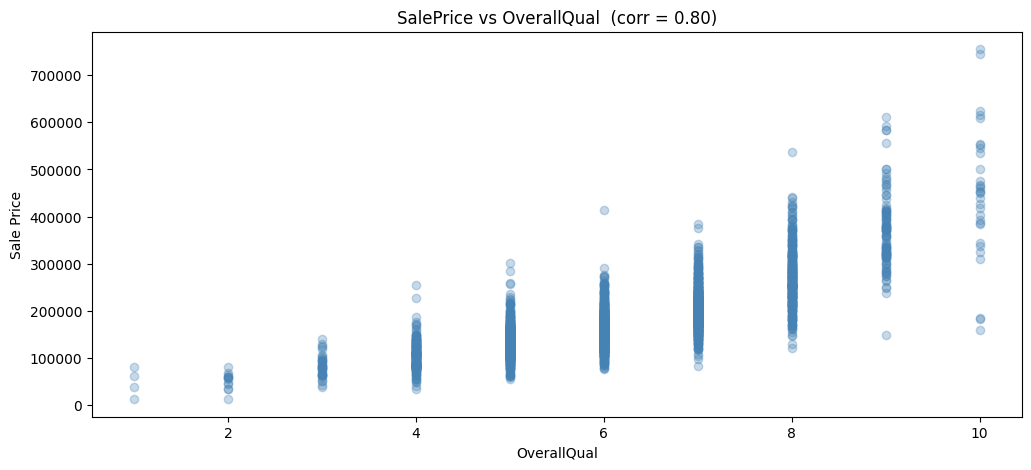

In [22]:
# Fallback scatterplot (only run if boxplot looks cluttered)
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df[most_pos_col], df['SalePrice'], alpha=0.3, color='steelblue')
ax.set_title(f'SalePrice vs {most_pos_col}  (corr = {most_pos_val:.2f})')
ax.set_xlabel(most_pos_col)
ax.set_ylabel('Sale Price')
plt.show()

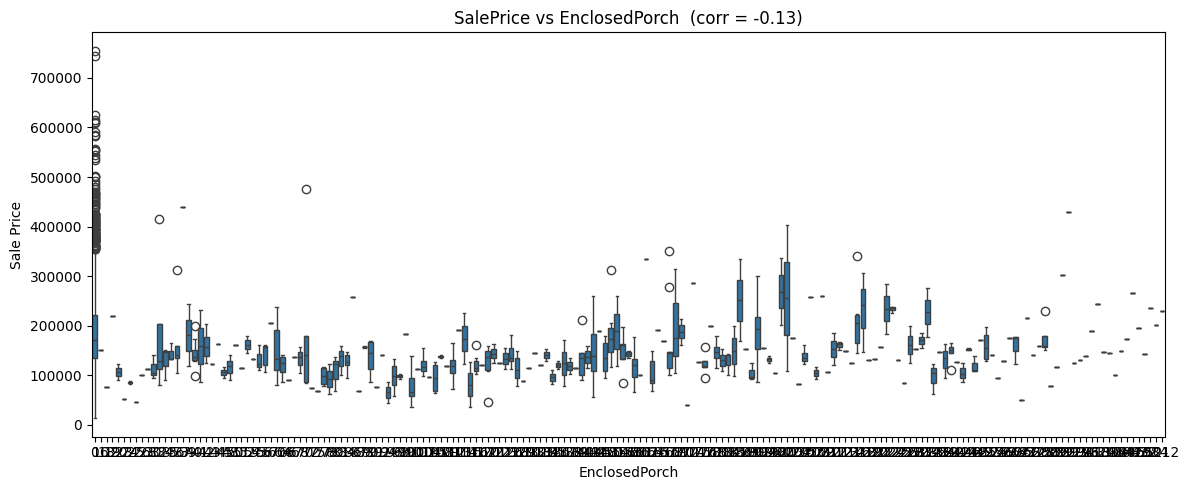

In [23]:
# ============================================================
# CELL 10: Box plot — most negatively correlated feature
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x=df[most_neg_col], y=df['SalePrice'], ax=ax)
ax.set_title(f'SalePrice vs {most_neg_col}  (corr = {most_neg_val:.2f})')
ax.set_xlabel(most_neg_col)
ax.set_ylabel('Sale Price')
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 11: Look at year-sold distribution
# ============================================================
df['YrSold'].value_counts().sort_index()

,count
YrSold,
2006,625
2007,694
2008,622
2009,648
2010,341


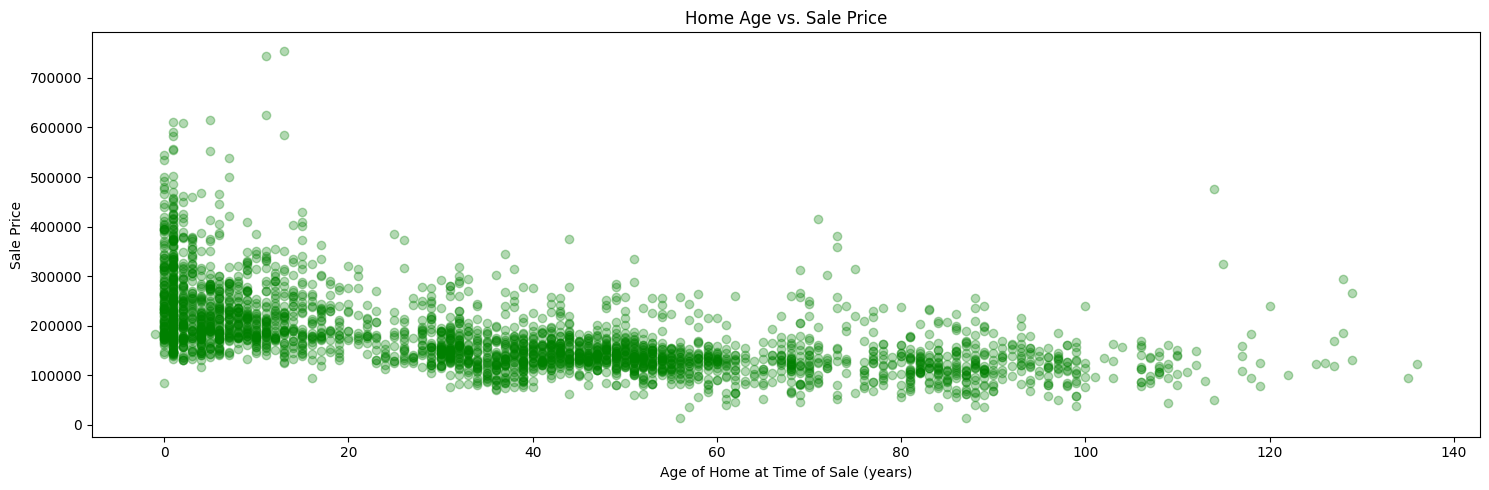

Correlation Age vs SalePrice: -0.559


In [25]:
# ============================================================
# CELL 12: Engineer 'Age' and plot vs SalePrice
# ============================================================
df['Age'] = df['YrSold'] - df['YearBuilt']

fig, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df['Age'], df['SalePrice'], alpha=0.3, color='green')
ax.set_title('Home Age vs. Sale Price')
ax.set_xlabel('Age of Home at Time of Sale (years)')
ax.set_ylabel('Sale Price')
plt.tight_layout()
plt.show()

print("Correlation Age vs SalePrice:", round(df['Age'].corr(df['SalePrice']), 3))

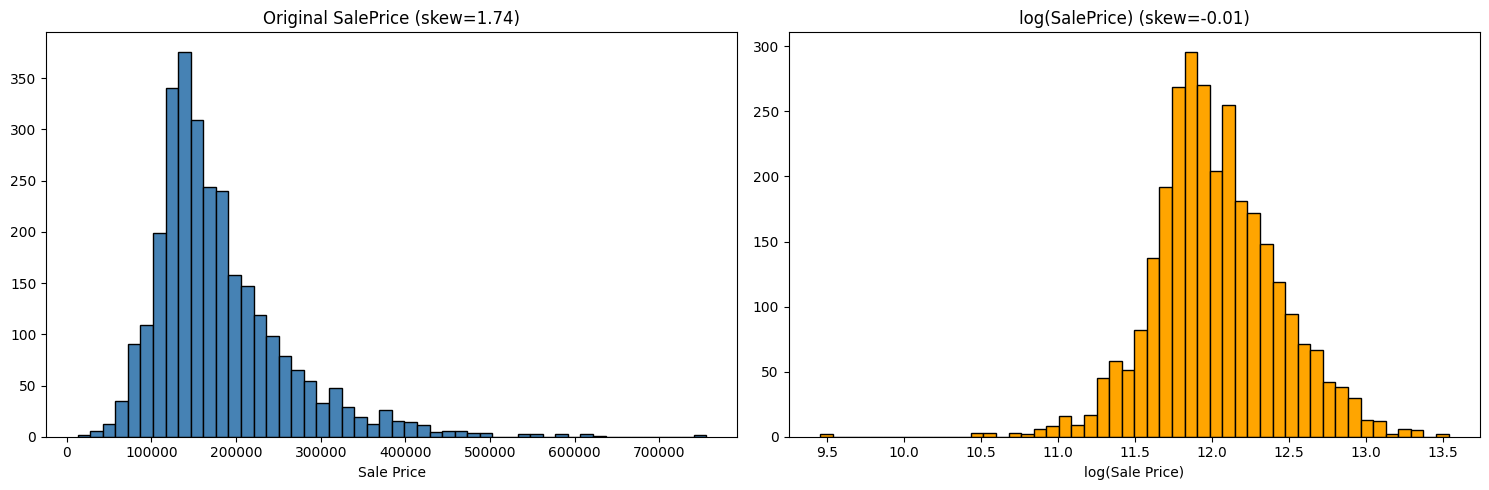

In [26]:
# ============================================================
# CELL 13 (Bonus): Log-transform SalePrice to reduce skew
# ============================================================
df['LogSalePrice'] = np.log(df['SalePrice'])

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

ax1.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
ax1.set_title(f"Original SalePrice (skew={df['SalePrice'].skew():.2f})")
ax1.set_xlabel('Sale Price')

ax2.hist(df['LogSalePrice'], bins=50, color='orange', edgecolor='black')
ax2.set_title(f"log(SalePrice) (skew={df['LogSalePrice'].skew():.2f})")
ax2.set_xlabel('log(Sale Price)')

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CELL 14: Summary snapshot
# ============================================================
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Nulls: {df.isnull().sum().sum()}")
print()
print("SalePrice stats:")
print(f"  Mean:   ${df['SalePrice'].mean():,.0f}")
print(f"  Median: ${df['SalePrice'].median():,.0f}")
print(f"  Std:    ${df['SalePrice'].std():,.0f}")
print(f"  Skew:   {df['SalePrice'].skew():.2f}")
print()
print(f"Top predictor: {most_pos_col} (corr={most_pos_val:.2f})")
print(f"Age vs SalePrice corr: {df['Age'].corr(df['SalePrice']):.2f}")
print("=" * 50)

DATASET SUMMARY
Rows: 2930
Columns: 82
Nulls: 15749

SalePrice stats:
  Mean:   $180,796
  Median: $160,000
  Std:    $79,887
  Skew:   1.74

Top predictor: OverallQual (corr=0.80)
Age vs SalePrice corr: -0.56


In [28]:
# ============================================================
# CELL 15: Diagnose nulls
# ============================================================
# Reload fresh if needed (in case you modified df during EDA)
import pandas as pd
import numpy as np

df = pd.read_csv('data/AmesHousing.csv')
if 'Order' in df.columns:
    df = df.drop(columns=['Order'])
if 'PID' in df.columns:
    df = df.set_index('PID')
df.columns = df.columns.str.replace(' ', '', regex=False)

# Total nulls
print(f"Total nulls: {df.isnull().sum().sum()}")
print(f"Total cells: {df.shape[0] * df.shape[1]}")
print(f"% missing:  {100 * df.isnull().sum().sum() / (df.shape[0] * df.shape[1]):.2f}%")

# Nulls per column
null_counts = df.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts > 0]
print(f"\nColumns with nulls: {len(null_counts)}")
print(null_counts)

Total nulls: 15749
Total cells: 234400
% missing:  6.72%

Columns with nulls: 27
PoolQC          2917
MiscFeature     2824
Alley           2732
Fence           2358
MasVnrType      1775
FireplaceQu     1422
LotFrontage      490
GarageYrBlt      159
GarageQual       159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      83
BsmtFinType2      81
BsmtQual          80
BsmtFinType1      80
BsmtCond          80
MasVnrArea        23
BsmtFullBath       2
BsmtHalfBath       2
BsmtFinSF2         1
GarageArea         1
TotalBsmtSF        1
BsmtFinSF1         1
Electrical         1
BsmtUnfSF          1
GarageCars         1
dtype: int64


In [30]:
# ============================================================
# CELL 16: Peek at some null-heavy columns
# ============================================================
# For each column, check: does null mean "None" or "truly missing"?
for col in ['PoolQC', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'BsmtQual']:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print(f"  Non-null values: {df[col].dropna().unique()[:5]}")
        print(f"  Null count: {df[col].isnull().sum()}")


=== PoolQC ===
  Non-null values: ['Ex' 'Gd' 'TA' 'Fa']
  Null count: 2917

=== Alley ===
  Non-null values: ['Pave' 'Grvl']
  Null count: 2732

=== Fence ===
  Non-null values: ['MnPrv' 'GdPrv' 'GdWo' 'MnWw']
  Null count: 2358

=== FireplaceQu ===
  Non-null values: ['Gd' 'TA' 'Po' 'Ex' 'Fa']
  Null count: 1422

=== GarageType ===
  Non-null values: ['Attchd' 'BuiltIn' 'Basment' 'Detchd' 'CarPort']
  Null count: 157

=== BsmtQual ===
  Non-null values: ['TA' 'Gd' 'Ex' 'Fa' 'Po']
  Null count: 80


In [31]:
# ============================================================
# CELL 17: Clean nulls with domain logic
# ============================================================
# 1. CATEGORICAL cols where null = "None" (feature doesn't exist)
cat_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
# Only fill columns that actually exist in df
cat_none_cols = [c for c in cat_none_cols if c in df.columns]
df[cat_none_cols] = df[cat_none_cols].fillna("None")

# 2. NUMERIC cols where null = 0 (no garage / no basement / no masonry)
num_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
num_zero_cols = [c for c in num_zero_cols if c in df.columns]
df[num_zero_cols] = df[num_zero_cols].fillna(0)

# 3. LotFrontage — genuinely missing, impute by neighborhood median
if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
                          .transform(lambda x: x.fillna(x.median()))

# 4. Remaining categorical nulls → fill with mode
remaining_cat = df.select_dtypes(include='object').columns
for c in remaining_cat:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

# 5. Remaining numeric nulls → fill with median
remaining_num = df.select_dtypes(include='number').columns
for c in remaining_num:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Verify clean
print(f"Total nulls after cleaning: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Total nulls after cleaning: 0
Shape: (2930, 80)


In [32]:
# ============================================================
# CELL 18: Verify no nulls remain
# ============================================================
assert df.isnull().sum().sum() == 0, "Still have nulls!"
print("✅ No nulls remain.")

# Compare dtypes
print("\nDtype breakdown:")
print(df.dtypes.value_counts())

✅ No nulls remain.

Dtype breakdown:
object     43
int64      26
float64    11
Name: count, dtype: int64


In [33]:
# ============================================================
# CELL 19: Split target and identify feature types
# ============================================================
target = 'SalePrice'

y = df[target]
X = df.drop(columns=[target])

# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features:     {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"\nSample categorical cols: {cat_cols[:10]}")

Numeric features:     36
Categorical features: 43

Sample categorical cols: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [34]:
# ============================================================
# CELL 20: Train/test split
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (2344, 79)
Test size:  (586, 79)


In [35]:
# ============================================================
# CELL 21: Preprocessing pipeline
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numeric pipeline: scale
num_transformer = StandardScaler()

# Categorical pipeline: one-hot encode
# handle_unknown='ignore' prevents crashes on unseen categories at test time
cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

print("✅ Preprocessor ready.")
print(f"Will transform {len(num_cols)} numeric + {len(cat_cols)} categorical columns.")

✅ Preprocessor ready.
Will transform 36 numeric + 43 categorical columns.


In [36]:
# ============================================================
# CELL 22: Evaluation helper
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train and evaluate a model, printing key metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"  MAE:  ${mae:,.0f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R²:   {r2:.4f}")
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}

In [37]:
# ============================================================
# CELL 23: Linear Regression — baseline
# ============================================================
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

results = []
results.append(evaluate_model('Linear Regression',
                               lr_pipeline,
                               X_train, y_train,
                               X_test, y_test))


=== Linear Regression ===
  MAE:  $15,679
  RMSE: $29,056
  R²:   0.8947


In [38]:
# ============================================================
# CELL 24: Ridge Regression
# ============================================================
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0, random_state=42))
])

results.append(evaluate_model('Ridge Regression',
                               ridge_pipeline,
                               X_train, y_train,
                               X_test, y_test))


=== Ridge Regression ===
  MAE:  $16,526
  RMSE: $29,014
  R²:   0.8950


In [39]:
# ============================================================
# CELL 25: Random Forest Regressor
# ============================================================
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

results.append(evaluate_model('Random Forest',
                               rf_pipeline,
                               X_train, y_train,
                               X_test, y_test))


=== Random Forest ===
  MAE:  $15,783
  RMSE: $27,300
  R²:   0.9070


             name          MAE         RMSE       R2
    Random Forest 15783.037039 27300.261240 0.907041
 Ridge Regression 16525.935677 29013.745682 0.895006
Linear Regression 15679.323356 29056.315782 0.894697


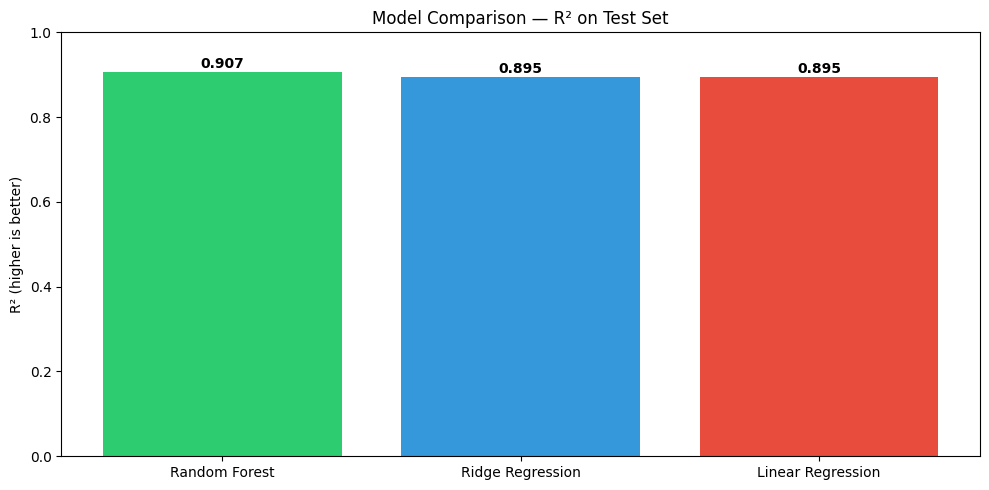

In [40]:
# ============================================================
# CELL 26: Compare models
# ============================================================
import pandas as pd

comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'model'}
    for r in results
])
comparison = comparison.sort_values('R2', ascending=False)

print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison['name'], comparison['R2'], color=['#2ecc71', '#3498db', '#e74c3c'])
ax.set_ylabel('R² (higher is better)')
ax.set_title('Model Comparison — R² on Test Set')
ax.set_ylim(0, 1)
for i, v in enumerate(comparison['R2']):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

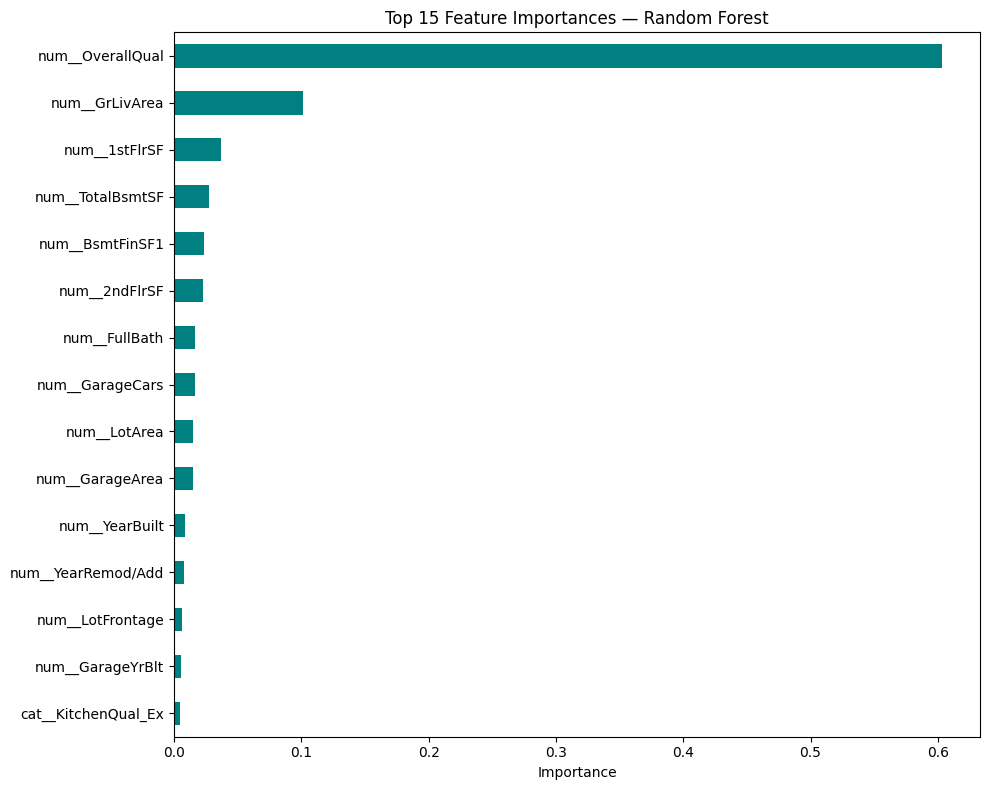

num__OverallQual       0.602967
num__GrLivArea         0.101544
num__1stFlrSF          0.036751
num__TotalBsmtSF       0.027041
num__BsmtFinSF1        0.023306
num__2ndFlrSF          0.022990
num__FullBath          0.016655
num__GarageCars        0.016189
num__LotArea           0.014919
num__GarageArea        0.014688
num__YearBuilt         0.008873
num__YearRemod/Add     0.007646
num__LotFrontage       0.006222
num__GarageYrBlt       0.005042
cat__KitchenQual_Ex    0.004883
dtype: float64


In [41]:
# ============================================================
# CELL 27: Top 15 feature importances (Random Forest)
# ============================================================
rf_model = results[-1]['model']  # last model = Random Forest
preproc = rf_model.named_steps['preprocessor']
rf = rf_model.named_steps['model']

# Get feature names after one-hot encoding
feature_names = preproc.get_feature_names_out()

importances = pd.Series(rf.feature_importances_, index=feature_names)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
top15[::-1].plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(top15)

In [42]:
# ============================================================
# CELL 28: Log-transform target — usually boosts R²
# ============================================================
y_log = np.log(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# But we need original-scale y_test to compute real $ metrics
_, X_test_orig, _, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_log_pipeline.fit(X_train, y_train_log)
y_pred_log = lr_log_pipeline.predict(X_test)
y_pred = np.exp(y_pred_log)  # convert back to dollars

mae  = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2   = r2_score(y_test_orig, y_pred)

print("=== Linear Regression on log(SalePrice) ===")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R²:   {r2:.4f}")
print("\nCompare to previous Linear Regression R² above.")

=== Linear Regression on log(SalePrice) ===
  MAE:  $14,710
  RMSE: $38,614
  R²:   0.8140

Compare to previous Linear Regression R² above.
